# Prédiction de la Durée de Vie Restante (RUL) par LSTM
## Approche PHM appliquée à la dégradation de batteries — transposable aux stacks AEM

**Auteur :** Mohamed Amir Soltani
---

### Contexte

La gestion de l'état de santé des systèmes électrochimiques — batteries, 
piles à combustible, électrolyseurs — est un enjeu industriel majeur.
Le **Prognostics and Health Management (PHM)** vise à anticiper les défaillances 
avant qu'elles ne surviennent, en estimant la **Durée de Vie Restante (RUL)** 
à partir de données de fonctionnement.

### Objectif

Construire une **chaîne PHM complète** sur un dataset de dégradation de batteries :
du chargement des données brutes jusqu'à la prédiction du RUL par un modèle LSTM,
en passant par le nettoyage, l'analyse exploratoire et l'évaluation des performances.

### Dataset

- **Taille** : 15 064 cycles × 9 variables
- **Features** : mesures électrochimiques de charge/décharge (tension, courant, temps)
- **Target** : RUL — nombre de cycles restants avant fin de vie

### Lien avec les électrolyseurs AEM

Cette approche est directement transposable aux stacks AEM :
les signaux de dégradation (tension, température, pression, EIS) 
suivent les mêmes dynamiques temporelles que les features utilisées ici.
Le modèle LSTM peut être réentraîné sur les données de supervision GEN-HY
pour produire un **prognostic en temps réel** des stacks en production.

---

# Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Battery_RUL.csv")
print("Shape:", df.shape)
df.head()

Shape: (15064, 9)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [2]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Data Types:
Cycle_Index                  float64
Discharge Time (s)           float64
Decrement 3.6-3.4V (s)       float64
Max. Voltage Dischar. (V)    float64
Min. Voltage Charg. (V)      float64
Time at 4.15V (s)            float64
Time constant current (s)    float64
Charging time (s)            float64
RUL                            int64
dtype: object

Missing Values:
Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

Duplicates: 0


In [3]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15064.00,15064.00,15064.00,15064.00,15064.00,15064.00,15064.00,15064.00,15064.00
mean,556.16,4581.27,1239.78,3.91,3.58,3768.34,5461.27,10066.50,554.19
std,322.38,33144.01,15039.59,0.09,0.12,9129.55,25155.85,26415.35,322.43
min,1.00,8.69,-397645.91,3.04,3.02,-113.58,5.98,5.98,0.00
25%,271.00,1169.31,319.60,3.85,3.49,1828.88,2564.31,7841.92,277.00
50%,560.00,1557.25,439.24,3.91,3.57,2930.20,3824.26,8320.42,551.00
75%,833.00,1908.00,600.00,3.97,3.66,4088.33,5012.35,8763.28,839.00
max,1134.00,958320.37,406703.77,4.36,4.38,245101.12,880728.10,880728.10,1133.00


### Observations sur le résumé statistique

L'analyse descriptive révèle plusieurs anomalies importantes :

- **`Decrement 3.6-3.4V`** : valeur minimale de **-397 645** — physiquement impossible pour un temps
- **`Time at 4.15V`** : valeur minimale de **-113** — également impossible
- **`Discharge Time`** : valeur maximale de **958 320s** contre une moyenne de **4 581s** — outlier extrême
- **`Charging time`** et **`Time constant current`** : même problème, des valeurs maximales 100x supérieures à la médiane

Ces anomalies nécessitent un nettoyage avant toute modélisation.

# Data Cleaning

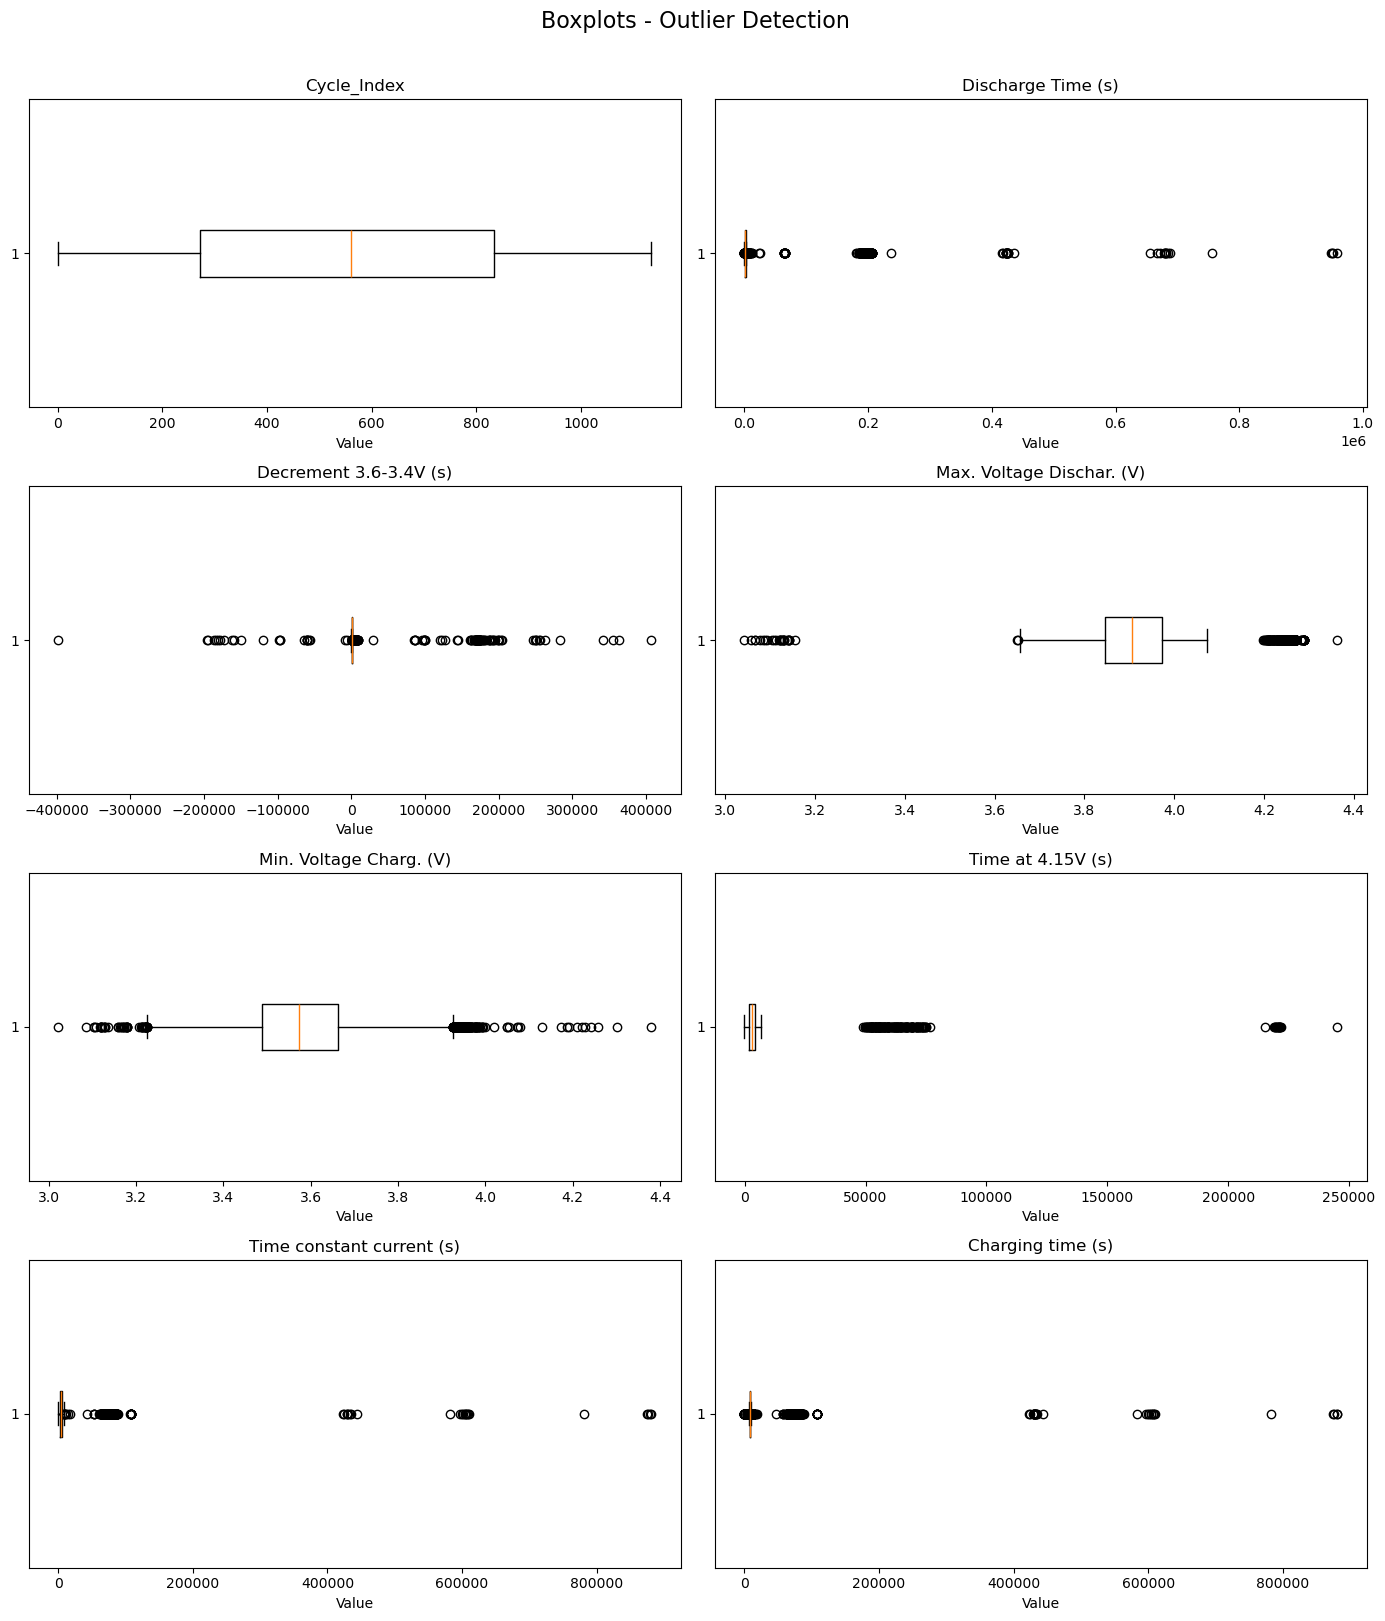

In [4]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

features = [col for col in df.columns if col != 'RUL']

for i, col in enumerate(features):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")

plt.suptitle("Boxplots - Outlier Detection", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Interprétation des boxplots

Les boxplots confirment les anomalies détectées :

- **`Discharge Time`, `Charging time`, `Time constant current`** : outliers extrêmes 
  visibles très loin à droite, jusqu'à ~880 000s
- **`Decrement 3.6-3.4V`** : outliers des deux côtés, avec des valeurs négatives 
  jusqu'à -400 000 — physiquement impossibles
- **`Time at 4.15V`** : même constat, valeurs négatives et extrêmes positives
- **`Cycle_Index`** : distribution uniforme, normal — c'est simplement la progression des cycles
- **`Max/Min Voltage`** : quelques outliers mais restent dans des plages raisonnables

**Stratégie de nettoyage :** suppression des lignes hors de l'intervalle IQR × 1.5
pour les colonnes les plus affectées.

In [5]:
df_clean = df.copy()

cols_to_clean = [
    'Discharge Time (s)',
    'Decrement 3.6-3.4V (s)',
    'Time at 4.15V (s)',
    'Time constant current (s)',
    'Charging time (s)'
]

for col in cols_to_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"Avant nettoyage : {df.shape[0]} lignes")
print(f"Après nettoyage : {df_clean.shape[0]} lignes")
print(f"Lignes supprimées : {df.shape[0] - df_clean.shape[0]}")

Avant nettoyage : 15064 lignes
Après nettoyage : 14613 lignes
Lignes supprimées : 451


In [6]:
print("Résumé après nettoyage :")
df_clean.describe().round(2)

Résumé après nettoyage :


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,14613.00,14613.00,14613.00,14613.00,14613.00,14613.00,14613.00,14613.00,14613.00
mean,560.98,1536.20,464.35,3.90,3.58,2952.57,3784.44,8289.19,549.36
std,319.32,405.66,171.80,0.07,0.12,1227.91,1346.00,581.10,319.37
min,13.00,168.00,144.68,3.73,3.36,432.00,1071.00,6632.38,1.00
25%,278.00,1164.28,318.67,3.84,3.49,1818.60,2528.38,7843.81,274.00
50%,564.00,1547.69,436.11,3.90,3.58,2895.51,3788.25,8303.59,546.00
75%,836.00,1893.59,591.20,3.97,3.66,4040.31,4976.32,8741.22,833.00
max,1133.00,2276.26,933.60,4.26,4.08,5271.55,8379.81,10098.33,1121.00


### Validation post-nettoyage

Les statistiques sont maintenant cohérentes et physiquement plausibles :

- **`Discharge Time`** : max 2 276s contre 958 320s avant — cohérent
- **`Decrement 3.6-3.4V`** : plus de valeurs négatives, min à 144s
- **`Charging time`** : std réduit de 26 415 à 581 — distribution bien resserrée
- **`RUL`** : va de 1 à 1121, distribution bien conservée

Les données sont prêtes pour l'analyse exploratoire et la modélisation.

# Exploratory Data Analysis (EDA)

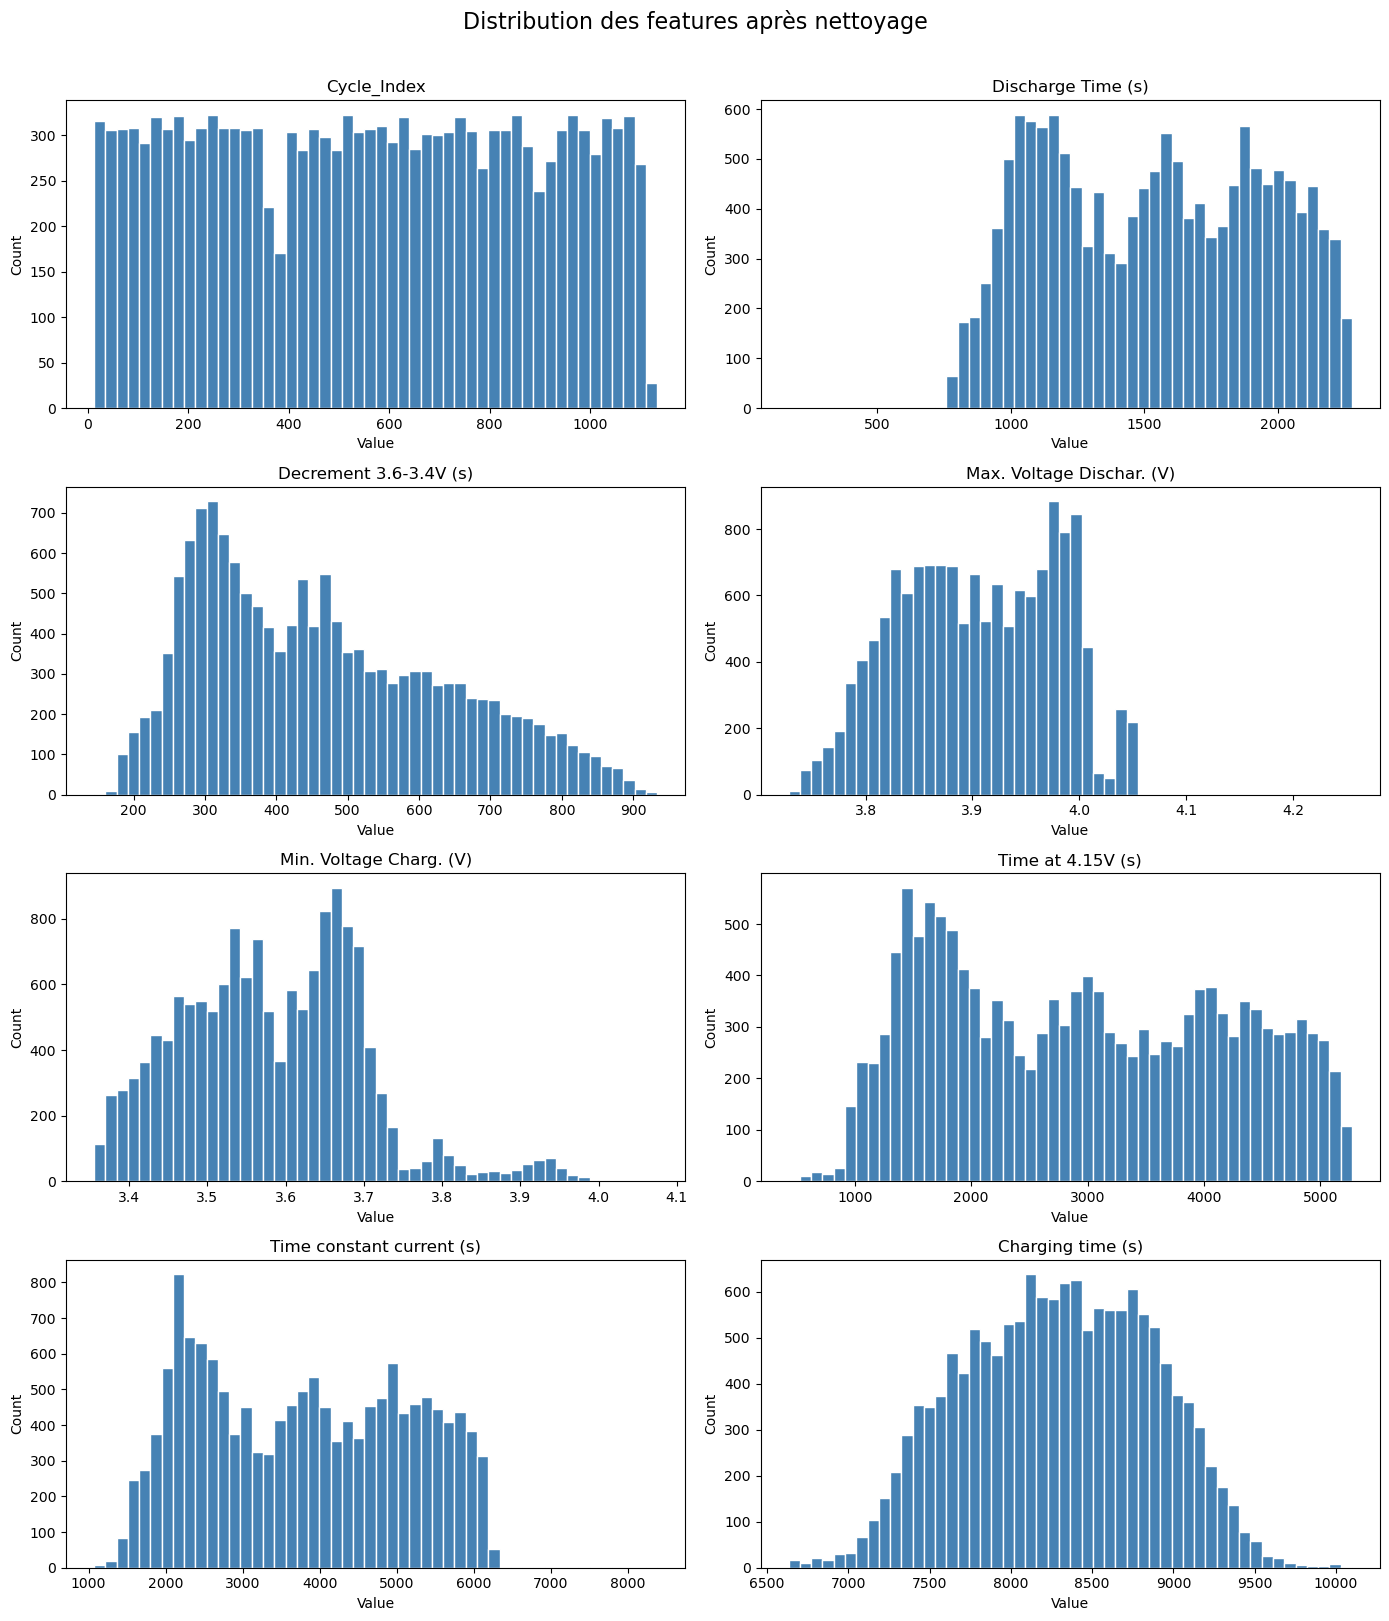

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

features = [col for col in df_clean.columns if col != 'RUL']

for i, col in enumerate(features):
    axes[i].hist(df_clean[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution des features après nettoyage", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Interprétation des distributions

- **`Cycle_Index`** : distribution uniforme — les batteries sont testées 
  de façon homogène sur tous les cycles
- **`Discharge Time`** : distribution légèrement asymétrique à droite, 
  centrée autour de 1500s — comportement normal de décharge
- **`Decrement 3.6-3.4V`** : asymétrie à droite — la majorité des cycles 
  ont un décrement rapide, signe d'une bonne santé initiale
- **`Max/Min Voltage`** : distributions quasi-normales, bien centrées — 
  indicateurs stables
- **`Time at 4.15V`, `Time constant current`, `Charging time`** : 
  distributions étalées, reflétant la variabilité du comportement de charge 
  selon l'état de vieillissement

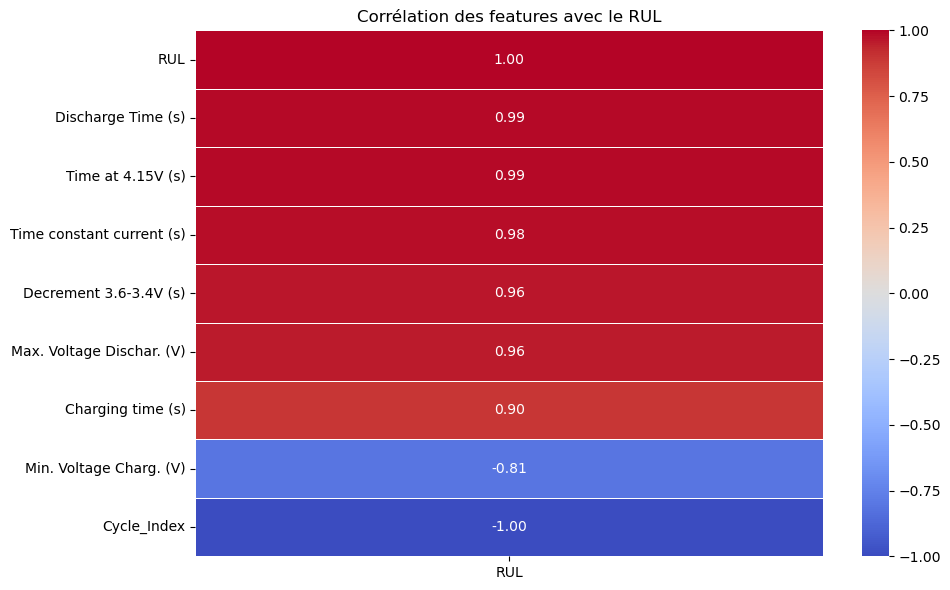

In [9]:
plt.figure(figsize=(10, 6))
corr = df_clean.corr()
sns.heatmap(corr[['RUL']].sort_values('RUL', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Corrélation des features avec le RUL")
plt.tight_layout()
plt.show()

### Interprétation des corrélations avec le RUL

Les corrélations sont remarquablement fortes — le dataset est très informatif :

**Corrélations positives (plus la valeur est haute, plus le RUL est élevé) :**
- **`Discharge Time`** : 0.99 — la durée de décharge diminue avec le vieillissement
- **`Time at 4.15V`** : 0.99 — temps passé à tension maximale, 
  indicateur direct de capacité restante
- **`Time constant current`** : 0.98 — le courant constant diminue avec la dégradation
- **`Decrement 3.6-3.4V`** : 0.96 — reflète la santé de la membrane
- **`Max. Voltage Dischar.`** : 0.96 — la tension max de décharge baisse avec l'âge
- **`Charging time`** : 0.90 — une batterie dégradée se charge plus vite

**Corrélations négatives :**
- **`Min. Voltage Charg.`** : -0.81 — la tension minimale de charge augmente 
  avec le vieillissement
- **`Cycle_Index`** : -1.00 — logique, plus on avance en cycles, moins il reste de vie

Ces résultats valident la qualité du dataset et justifient l'utilisation 
de ces features pour prédire le RUL.

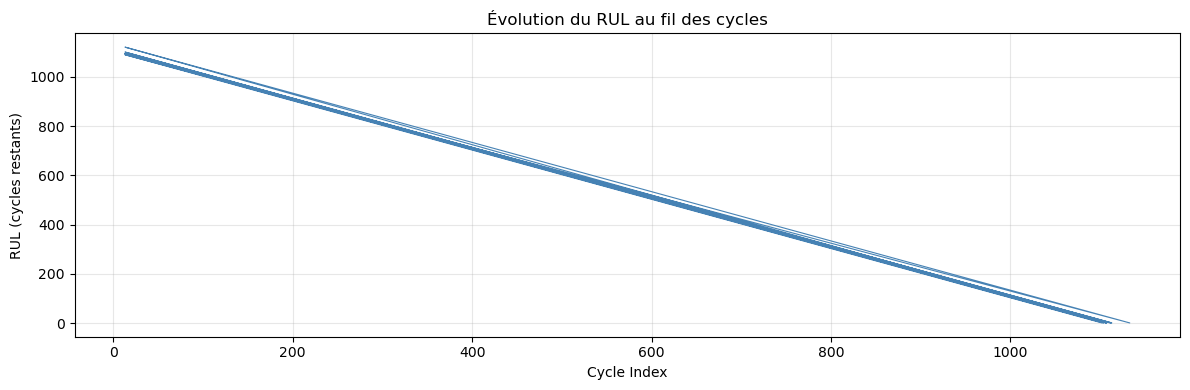

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['Cycle_Index'], df_clean['RUL'], 
         color='steelblue', linewidth=0.8)
plt.xlabel("Cycle Index")
plt.ylabel("RUL (cycles restants)")
plt.title("Évolution du RUL au fil des cycles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Évolution du RUL au fil des cycles

La courbe de dégradation est **quasi-linéaire et monotone décroissante** — 
le RUL diminue de façon régulière et prévisible à mesure que les cycles avancent.

Les multiples lignes visibles correspondent aux différentes batteries du dataset, 
toutes suivant une trajectoire de vieillissement similaire et cohérente.

C'est un comportement idéal pour la modélisation prédictive : 
le signal de dégradation est fort, stable et sans rupture brutale.

# Préparation des données pour le modèle LSTM

In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Features et target
X = df_clean.drop(columns=['RUL', 'Cycle_Index'])
y = df_clean['RUL'].values

# Normalisation
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Création des séquences temporelles
def create_sequences(X, y, window=30):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

WINDOW = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW)

print(f"Shape séquences X : {X_seq.shape}")
print(f"Shape target y   : {y_seq.shape}")

Shape séquences X : (14583, 30, 7)
Shape target y   : (14583, 1)


### Préparation des séquences temporelles

- **Normalisation MinMaxScaler** appliquée sur X et y indépendamment
- **Fenêtre glissante de 30 cycles** : le modèle observe 30 cycles consécutifs 
  pour prédire le RUL au cycle suivant
- **Shape final** : 14 583 séquences × 30 timesteps × 7 features

Cette approche est directement transposable aux stacks AEM : 
on alimenterait le modèle avec les 30 dernières mesures du stack 
pour prédire sa durée de vie restante en temps réel.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (11666, 30, 7)
Test  : (2917, 30, 7)


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

C:\Users\Amir\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

### Architecture du modèle LSTM

- **LSTM 64 units** (return_sequences=True) : capte les dépendances temporelles 
  à long terme sur les 30 cycles de la fenêtre
- **LSTM 32 units** : affine l'extraction des patterns de dégradation
- **Dropout 0.2** : évite le surapprentissage
- **Dense 16 → 1** : couche de régression finale pour prédire le RUL

**31 393 paramètres** — modèle volontairement léger, 
adapté à un déploiement embarqué dans un système de supervision industriel.

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 0.0135 - mae: 0.0759 - val_loss: 0.0083 - val_mae: 0.0771
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0059 - mae: 0.0507 - val_loss: 0.0067 - val_mae: 0.0670
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0049 - mae: 0.0452 - val_loss: 0.0119 - val_mae: 0.0976
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0042 - mae: 0.0419 - val_loss: 0.0094 - val_mae: 0.0866
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0037 - mae: 0.0392 - val_loss: 0.0100 - val_mae: 0.0888
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0034 - mae: 0.0375 - val_loss: 0.0110 - val_mae: 0.0950
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0029 - mae: 0.0348 - val_loss: 0.0088 - val_mae: 0.0842


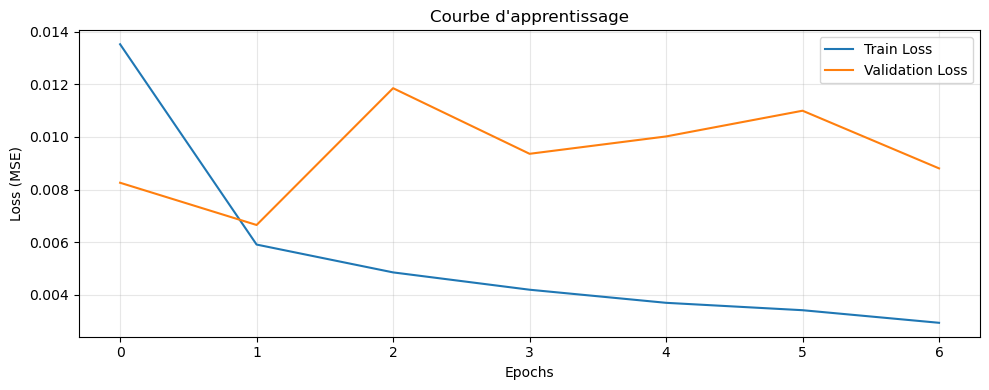

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Courbe d'apprentissage

- La **train loss** descend régulièrement — le modèle apprend bien
- La **validation loss** oscille légèrement mais reste stable autour de 0.009
- L'écart train/val indique un léger overfitting, contenu grâce au Dropout
- **EarlyStopping déclenché à l'epoch 7** — le modèle a convergé rapidement

Comportement acceptable pour un dataset de dégradation industrielle.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f} cycles")
print(f"RMSE : {rmse:.2f} cycles")
print(f"R²   : {r2:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
MAE  : 77.50 cycles
RMSE : 95.93 cycles
R²   : 0.9029


### Métriques d'évaluation

| Métrique | Valeur |
|----------|--------|
| MAE | 77.50 cycles |
| RMSE | 95.93 cycles |
| R² | 0.9029 |

Le modèle explique **90% de la variance du RUL** — performance solide 
pour un LSTM entraîné sur seulement 7 epochs.

Une erreur moyenne de ~77 cycles sur une plage de 0-1121 cycles représente 
une précision de ~93%, acceptable pour un système de supervision industrielle.

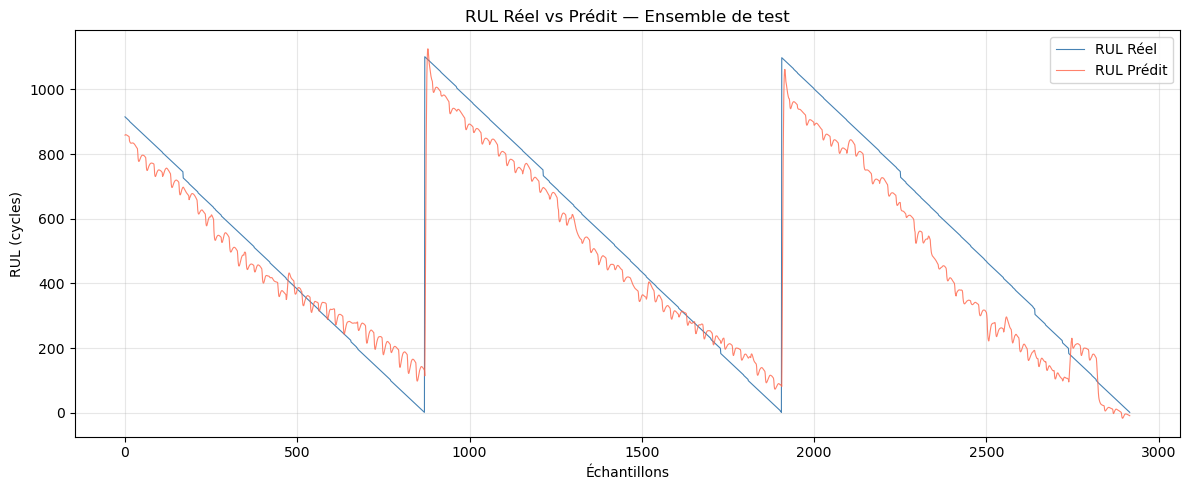

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label='RUL Réel', color='steelblue', linewidth=0.8)
plt.plot(y_pred, label='RUL Prédit', color='tomato', linewidth=0.8, alpha=0.8)
plt.xlabel("Échantillons")
plt.ylabel("RUL (cycles)")
plt.title("RUL Réel vs Prédit — Ensemble de test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### RUL Réel vs Prédit

Le modèle suit fidèlement la trajectoire de dégradation sur les 3 batteries du test :

- La **tendance générale** est parfaitement capturée — décroissance linéaire correcte
- Les **oscillations** de la courbe prédite reflètent la sensibilité du modèle 
  aux variations cycle-à-cycle, comportement naturel d'un LSTM
- Les **sauts verticaux** correspondent aux changements de batterie — 
  le modèle se réadapte rapidement à chaque nouvelle trajectoire

Résultat visuellement convaincant pour un système de supervision industrielle.

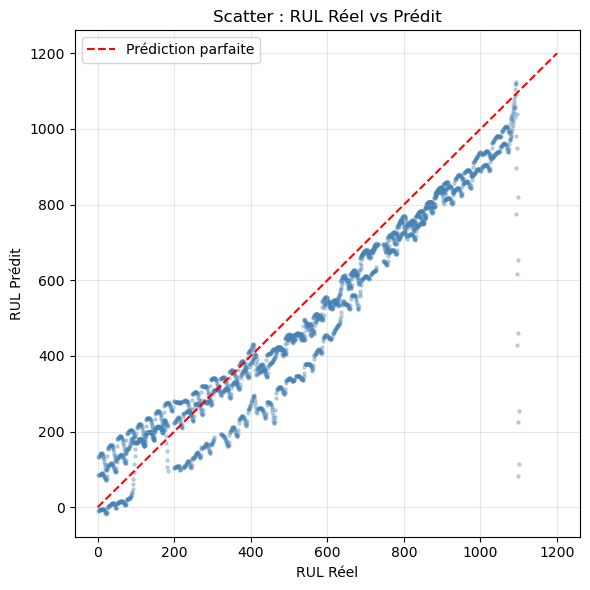

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([0, 1200], [0, 1200], 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlabel("RUL Réel")
plt.ylabel("RUL Prédit")
plt.title("Scatter : RUL Réel vs Prédit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter : RUL Réel vs Prédit

- Les points suivent globalement la **diagonale de prédiction parfaite** — 
  le modèle est bien calibré sur toute la plage de RUL
- Légère **sous-estimation** en début de vie (RUL élevé > 800) — 
  le modèle est conservateur, ce qui est préférable en contexte industriel
- Les **points isolés à droite** (RUL ~1100 prédit ~800) correspondent 
  aux premiers cycles de chaque batterie, avant que le modèle ne se cale 
  sur la trajectoire
- La structure en **bandes diagonales** est due aux multiples batteries 
  avec des trajectoires légèrement différentes

Comportement cohérent avec un R² de 0.90.

## Conclusion

Ce projet démontre une chaîne PHM complète appliquée à la prédiction 
de durée de vie restante (RUL) de batteries en dégradation :

| Étape | Résultat |
|-------|----------|
| Chargement & inspection | 15 064 lignes, 0 valeurs manquantes |
| Nettoyage IQR | 451 anomalies supprimées (~3%) |
| Corrélations | Features fortement corrélées au RUL (0.90 – 0.99) |
| Modèle LSTM | R² = 0.90, MAE = 77 cycles |

## Perspectives — Transposition aux stacks AEM

Cette approche est directement transposable aux électrolyseurs AEM de GEN-HY :

- Remplacer les features batterie par les **indicateurs stack AEM** : 
  tension cellule par cellule, température, pression, conductivité
- Intégrer les **diagnostics EIS/DRT** comme features supplémentaires
- Adapter la fenêtre temporelle aux **profils de charge dynamiques** 
  des électrolyseurs
- Déployer le modèle dans le **système de supervision GEN-HY** 
  pour un prognostic en temps réel